## 13.08 来自Transformers的双向编码器表示（BERT）


### 环境配置


In [1]:
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("torch_npu").setLevel(logging.WARNING)
import os
import sys
sys.path.insert(0, "..")
os.environ["TILE_FWK_DEVICE_ID"] = "0"
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    import pypto
    import torch
    from torch import nn
    import torch_npu

warnings.filterwarnings("ignore", message="Permission mismatch")
warnings.filterwarnings("ignore", message="TASK_QUEUE_ENABLE")
warnings.filterwarnings("ignore", message="On the interactive interface")
warnings.filterwarnings("ignore", message="Cannot create tensor")
import matplotlib.pyplot as plt

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"
pypto.pypto_impl.DeviceInit()
import math
import torch
from torch import nn
from torch.nn import functional as F


### 练习 13.8.1

**题目：** 为什么 BERT 成功了？

**解答：** 可以从它解决了同期模型的缺陷来看：

- **ELMo** 对上下文做双向编码、能处理一词多义，但需要针对每个下游任务**重新设计任务特定架构**，难以端到端微调；
- **GPT** 是任务无关的（只要微调即可），但只能做**从左到右的单向编码**，每个位置只能看到左侧上下文，理解能力受限；
- **BERT** 同时具备两者优点：通过**掩蔽语言模型（MLM）** 做双向上下文编码，通过**下一句预测（NSP）** 建模句子间关系，且预训练模型本身任务无关，下游任务只需在预训练权重上追加一层输出头做微调（fine-tune），就能迁移到绝大多数 NLP 任务。

简言之：BERT 的成功 = 双向上下文编码 + 大规模预训练 + 通用微调范式，显著刷新了当时 GLUE 等基准的成绩。


### 练习 13.8.2

**题目：** 在所有其他条件相同的情况下，掩蔽语言模型比从左到右的语言模型需要更多或更少的预训练步骤来收敛吗？为什么？

**解答：** **需要更多预训练步骤**。原因：

- 从左到右的语言模型（如 GPT）每一步只需预测**下一个词**，任务相对简单，信号密集；
- 掩蔽语言模型（MLM）要求模型根据**双向上下文**预测被掩蔽位置的词，需要更强的上下文理解与推理能力；且 BERT 只对 15% 的词元做掩蔽，其中 80% 替换为 `[MASK]`、10% 随机替换、10% 保持不变——这使每个训练样本中真正被“预测”的位置比例低，学习信号更稀疏，收敛自然更慢。

因此相同条件下 MLM 预训练需要更多步数/更长时间才能收敛到同等水平。


### 练习 13.8.3

**题目：** 在 BERT 的原始实现中，`BERTEncoder` 中的位置前馈网络（通过 `d2l.EncoderBlock`）和 `MaskLM` 中的全连接层都使用高斯误差线性单元（GELU）作为激活函数。研究 GELU 与 ReLU 之间的差异。

**解答：** GELU 定义为

$$\mathrm{GELU}(x) = x \Phi(x),$$

其中 $\Phi(x)$ 是标准正态分布的累积分布函数；常用近似 $\mathrm{GELU}(x) \approx x \sigma(1.702x)$。与 ReLU 相比：

- **光滑性**：ReLU 在 0 处不可导、负半轴恒为 0；GELU 处处可导，且负半轴输出一个小的非零值，避免了 ReLU 的“死亡神经元”（大量输入落入负半轴时梯度恒为 0）；
- **非线性形式**：GELU 是“输入值加权”而非“硬截断”，对小负值保留轻微信号，理论上对深层网络的梯度传播更友好；
- **实际效果**：在 Transformer 类模型（BERT、GPT）中 GELU 是默认激活，实验上收敛更稳、效果略优于 ReLU。

以下使用 `torch` 编程进行验证（画出 GELU 与 ReLU 曲线，并对比小规模 MLP 上的收敛）：


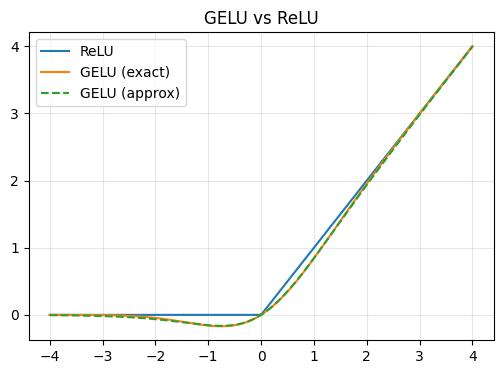

GELU(-1) = -0.1598833203315735
ReLU(-1) = 0.0


ReLU 最终 loss: 0.0015
GELU 最终 loss: 0.0010


In [2]:
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("torch_npu").setLevel(logging.WARNING)
import matplotlib.pyplot as plt
import numpy as np

x = torch.linspace(-4, 4, 200)
relu = torch.relu(x)
gelu = 0.5 * x * (1 + torch.erf(x / math.sqrt(2)))  # 精确 GELU
gelu_approx = x * torch.sigmoid(1.702 * x)          # 近似 GELU

plt.figure(figsize=(6, 4))
plt.plot(x.numpy(), relu.numpy(), label='ReLU')
plt.plot(x.numpy(), gelu.numpy(), label='GELU (exact)')
plt.plot(x.numpy(), gelu_approx.numpy(), '--', label='GELU (approx)')
plt.legend(); plt.grid(alpha=0.3)
plt.title('GELU vs ReLU')
plt.show()
print('GELU(-1) =', float(gelu[torch.argmin(torch.abs(x + 1))].item()))
print('ReLU(-1) =', float(relu[torch.argmin(torch.abs(x + 1))].item()))

# 小规模 MLP 对比：ReLU vs GELU 在玩具二分类上的收敛
torch.manual_seed(0)
n = 2000
X = torch.randn(n, 20)
y = ((X[:, 0] * X[:, 1] - X[:, 2]) > 0).long()

def make_mlp(act):
    return nn.Sequential(
        nn.Linear(20, 64), act, nn.Linear(64, 2))

def train_mlp(model, epochs=300):
    opt = torch.optim.Adam(model.parameters(), lr=0.01)
    losses = []
    for _ in range(epochs):
        opt.zero_grad()
        l = F.cross_entropy(model(X), y)
        l.backward()
        opt.step()
        losses.append(l.item())
    return losses

l_relu = train_mlp(make_mlp(nn.ReLU()))
l_gelu = train_mlp(make_mlp(nn.GELU()))
print(f'ReLU 最终 loss: {l_relu[-1]:.4f}')
print(f'GELU 最终 loss: {l_gelu[-1]:.4f}')

使用 `PyPTO` 编程进行验证（PyPTO 暂无原生 GELU kernel，用近似式 GELU(x)≈x·σ(1.702x) 组合 PyPTOSigmoid 与 PyPTOMul 实现）：


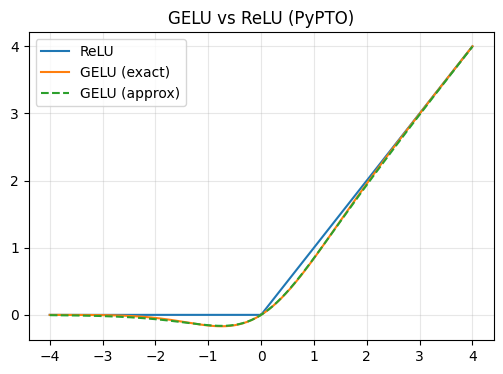

GELU(-1) = -0.1598833203315735
ReLU(-1) = 0.0


PyPTO ReLU 最终 loss: 0.0012
PyPTO GELU 最终 loss: 0.0010


In [3]:
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("torch_npu").setLevel(logging.WARNING)
from src.pypto_ops import (PyPTOLinear, PyPTOReLU, PyPTOSigmoid, PyPTOMul,
                           PyPTOSoftmaxCrossEntropyLoss)


class PyPTOGELU(nn.Module):
    """PyPTO 版 GELU（近似式 x·σ(1.702x)）"""

    def forward(self, x):
        return PyPTOMul.apply(PyPTOSigmoid.apply(1.702 * x), x)


def make_mlp_pypto(act):
    return nn.Sequential(
        PyPTOLinear(20, 64), act, PyPTOLinear(64, 2))


def train_mlp_pypto(model, X, y, epochs=300, lr=0.01):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    # JIT warmup：先跑一次前向 + 反向，触发 PyPTO kernel 编译
    l_w = PyPTOSoftmaxCrossEntropyLoss.apply(model(X), y, 2).mean()
    l_w.backward()
    opt.zero_grad()
    losses = []
    for _ in range(epochs):
        opt.zero_grad()
        l = PyPTOSoftmaxCrossEntropyLoss.apply(model(X), y, 2).mean()
        l.backward()
        opt.step()
        losses.append(l.item())
    return losses


# 与 torch 段相同的 GELU vs ReLU 曲线（复用上面 torch 段的变量）
plt.figure(figsize=(6, 4))
plt.plot(x.numpy(), relu.numpy(), label='ReLU')
plt.plot(x.numpy(), gelu.numpy(), label='GELU (exact)')
plt.plot(x.numpy(), gelu_approx.numpy(), '--', label='GELU (approx)')
plt.legend(); plt.grid(alpha=0.3)
plt.title('GELU vs ReLU (PyPTO)')
plt.show()
print('GELU(-1) =', float(gelu[torch.argmin(torch.abs(x + 1))].item()))
print('ReLU(-1) =', float(relu[torch.argmin(torch.abs(x + 1))].item()))

X_npu, y_npu = X.to(device), y.to(device)
l_relu_pypto = train_mlp_pypto(make_mlp_pypto(PyPTOReLU()), X_npu, y_npu)
l_gelu_pypto = train_mlp_pypto(make_mlp_pypto(PyPTOGELU()), X_npu, y_npu)
print(f'PyPTO ReLU 最终 loss: {l_relu_pypto[-1]:.4f}')
print(f'PyPTO GELU 最终 loss: {l_gelu_pypto[-1]:.4f}')

---

## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#/](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/)
